# Cook Data Exploration

## Imports

In [43]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

import keras # please install the keras package first
import keras.layers as layers
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error

## Data Import and Combine

In [ ]:
# Import files

crop_file_name = ""
terrain_file_name = ""

if 'google.colab' in sys.modules:
  drive.mount('/content/drive')
  crop_file_name = "/content/drive/MyDrive/Colab Notebooks/Capstone/Data/CookHandHarvest_HY1999-HY2016_P3A3_20241029(in).csv"
  terrain_file_name = "/content/drive/MyDrive/Colab Notebooks/Capstone/Data/CookTerrainAttributes10m2_P3A1_20210119.csv"
else:
  crop_file_name = "./Data/CookHandHarvest_HY1999-HY2016_P3A3_20241029(in).csv"
  terrain_file_name = "./Data/CookTerrainAttributes10m2_P3A1_20210119.csv"

print(crop_file_name)
print(terrain_file_name)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Capstone/Data/CookHandHarvest_HY1999-HY2016_P3A3_20241029(in).csv
/content/drive/MyDrive/Colab Notebooks/Capstone/Data/CookTerrainAttributes10m2_P3A1_20210119.csv


### Crop

In [ ]:
crop = pd.read_csv(crop_file_name)

In [ ]:
shape_before = crop.shape
print(shape_before)

(6642, 26)


In [ ]:
# drop any columns that are more than 1000 missing values
crop = crop.loc[:, crop.isna().sum() <= 1000]

# Drop unnecessary "SampleID" Column
crop.drop(columns=["SampleID"], inplace=True)

In [ ]:
# Drop rows with missing "Crop" or "GrainYieldAirDry" Values
crop = crop.dropna()
crop.isna().sum()

,0
HarvestYear,0
ID2,0
Longitude,0
Latitude,0
Crop,0
QCCoverage,0
QCFlags,0
CropExists,0
GrainYieldAirDry,0


In [ ]:
shape_after = crop.shape
print(shape_after)

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(6285, 9)
Dropped Column amount: 17
Dropped Row amount: 357


### Terrain

In [ ]:
terrain = pd.read_csv(terrain_file_name)

In [ ]:
terrain.head()

,ID2,FieldName,Latitude,Longitude,Elevation,AnalyticalHillshade,ConvergenceIndex,TotalCatchmentArea,TopographicWetnessIndex,LengthSlopeFactor,...,ChannelNetworkDistance,ValleyDepth,RelativeSlopePosition,Slope,Aspect,TRASP,ProfileCurvature,PlanCurvature,TangentialCurvature,AnnualGlobalSolarRadiation
0,1,CookEast,46.778729,-117.087514,781.48643,0.857087,3.197987,682.413452,5.702310,1.407364,...,2.433228,31.977112,0.070712,7.600873,195.363983,0.983775,-0.000807,-0.001175,-0.000155,1860.944336
1,2,CookEast,46.778692,-117.087065,782.43932,0.835344,-0.196646,1105.528442,6.433780,1.126312,...,2.692078,31.024231,0.079845,5.939017,198.724243,0.990349,-0.001025,-0.004596,-0.000476,1833.973389
2,3,CookEast,46.778791,-117.086678,784.93625,0.859389,1.008778,689.028320,5.602043,1.622139,...,4.639526,28.526917,0.139886,8.471982,198.494370,0.989953,-0.001278,0.009172,0.001351,1871.270264
3,4,CookEast,46.778761,-117.086260,786.42902,0.876073,-0.155071,865.019226,5.865278,1.622096,...,5.796997,27.032532,0.176579,8.178418,188.564774,0.965416,-0.000061,0.024965,0.003551,1873.524658
4,5,CookEast,46.778666,-117.085842,786.51237,0.843491,0.770311,563.946228,5.538609,1.308802,...,5.668457,26.945679,0.173804,7.400980,201.473892,0.994474,-0.001019,0.025449,0.003278,1853.676514


In [ ]:
shape_before = terrain.shape
print(shape_before)

(619, 21)


In [ ]:
terrain.isna().sum()

,0
ID2,0
FieldName,0
Latitude,0
Longitude,0
Elevation,0
AnalyticalHillshade,0
ConvergenceIndex,0
TotalCatchmentArea,0
TopographicWetnessIndex,0
LengthSlopeFactor,0


In [ ]:
shape_after = terrain.shape
print(shape_after)

print(f'Dropped Column amount: {shape_before[1] - shape_after[1]}')
print(f'Dropped Row amount: {shape_before[0] - shape_after[0]}')

(619, 21)
Dropped Column amount: 0
Dropped Row amount: 0


### Combine

In [ ]:
print(f"crop['ID2'].nunique(): {crop['ID2'].nunique()}")
print(f"terrain['ID2'].nunique(): {terrain['ID2'].nunique()}")

crop['ID2'].nunique(): 369
terrain['ID2'].nunique(): 619


`crop` only contains data from *Cook East* location but `terrain` contains data from *Cook East* and *Cook West*

In [ ]:
print(f"terrain['Longitude'].iloc[0]: {terrain['Longitude'].iloc[0]}")
print(f"crop['Longitude'].iloc[0]: {crop['Longitude'].iloc[0]}")

terrain['Longitude'].iloc[0]: -117.08751399999728
crop['Longitude'].iloc[0]: -117.087514


In [ ]:
# Combine "crop" and "terrain" dataframes on "ID2" column
combined = pd.merge(crop, terrain, on=["ID2"], how="inner")

**Note:** I tried to merge based off Longitude and Latitude but the "terrain" dataframes values are more precise so the values do not match (see cell above). This is why we merge based on "ID2" primarily. Later we should return to this and ensure that the ID2's Longitude and Latitude match.

In [ ]:
combined.shape

(6285, 29)

In [ ]:
combined.isna().sum()

,0
HarvestYear,0
ID2,0
Longitude_x,0
Latitude_x,0
Crop,0
QCCoverage,0
QCFlags,0
CropExists,0
GrainYieldAirDry,0
FieldName,0


## Data Exploration

In [ ]:
# Drop "QCCoverage" column becauuse it is NaN

combined.drop(columns=["QCCoverage"], inplace=True)

In [ ]:
# Remove the following to simplify the dataset
columns_to_remove = [
    "ID2",
    "HarvestYear",
    "Longitude_x",
    "Latitude_x",
    "Longitude_y",
    "Latitude_y",
    "FieldName",

]
combined.drop(columns=columns_to_remove, inplace=True)

In [ ]:
print(combined.columns.tolist())

['Crop', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


In [ ]:
combined.shape

(6285, 21)

In [ ]:
combined["GrainYieldAirDry"].max()

883.2212021

In [ ]:
combined["GrainYieldAirDry"].min()

0.0

In [ ]:
print(combined.columns.tolist())

['Crop', 'QCFlags', 'CropExists', 'GrainYieldAirDry', 'Elevation', 'AnalyticalHillshade', 'ConvergenceIndex', 'TotalCatchmentArea', 'TopographicWetnessIndex', 'LengthSlopeFactor', 'ChannelNetworkBaseLevel', 'ChannelNetworkDistance', 'ValleyDepth', 'RelativeSlopePosition', 'Slope', 'Aspect', 'TRASP', 'ProfileCurvature', 'PlanCurvature', 'TangentialCurvature', 'AnnualGlobalSolarRadiation']


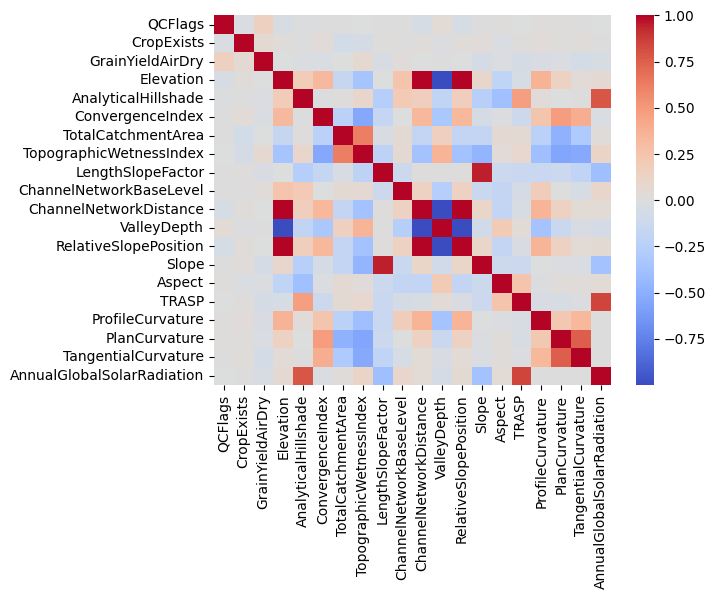

In [ ]:
corr = combined.select_dtypes(include="number").corr()

sns.heatmap(corr, cmap="coolwarm")
plt.show()


## Data Processing

### Encoding Categorical Values

In [ ]:
print(combined.select_dtypes(include=["object", "category"]).columns.tolist())


['Crop']


In [ ]:
le = LabelEncoder()
combined["Crop"] = le.fit_transform(combined["Crop"].astype(str))


In [ ]:
combined["Crop"].value_counts()

,count
Crop,
10,1981
4,1905
1,650
0,614
2,601
3,189
5,109
8,92
7,61


In [ ]:
print(combined.select_dtypes(include=["object", "category"]).columns.tolist())

[]


### Split

In [ ]:
target_column = "GrainYieldAirDry"

X = combined.drop(columns=[target_column])
y = combined[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scale

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

X_train, X_test, y_train, y_test

In [44]:
print(f'X_train.shape: {X_train.shape}')
print(f'X_train.shape: {X_test.shape}')
print(f'X_train.shape: {y_train.shape}')
print(f'X_train.shape: {y_test.shape}')

X_train.shape: (5028, 20)
X_train.shape: (1257, 20)
X_train.shape: (5028,)
X_train.shape: (1257,)


In [45]:
def Create_Model(input_dim):
    model = keras.models.Sequential()

    # Input layer
    model.add(keras.layers.Input(shape=(input_dim,)))

    # Hidden layers
    model.add(keras.layers.Dense(
        units=128,
        activation='relu',
        kernel_initializer='he_normal'
    ))
    model.add(keras.layers.Dense(
        units=64,
        activation='relu',
        kernel_initializer='he_normal'
    ))
    model.add(keras.layers.Dense(
        units=32,
        activation='relu',
        kernel_initializer='he_normal'
    ))
    # Optional regularization (uncomment if you see overfitting)
    # model.add(keras.layers.Dropout(0.2))

    # Output layer for regression (one continuous value)
    model.add(keras.layers.Dense(
        units=1,
        activation='linear',          # << no activation = regression
        kernel_initializer='glorot_uniform'
    ))

    # Compile for regression
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse',                   # mean squared error
        metrics=['mae']               # mean absolute error
    )

    return model


# Create model with correct input dimension
input_dim = X_train.shape[1]
model = Create_Model(input_dim)

model.summary()

# Early stopping (you already imported EarlyStopping)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model.fit(
    X_train, y_train,
    validation_split=0.2,   # use part of training data for validation
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0                # change to 1 to see progress
)

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)

# Predictions for extra metrics
y_pred = model.predict(X_test).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test R^2:  {r2:.4f}")


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test MSE:  17108.7680
Test RMSE: 130.8005
Test MAE:  104.3155
Test R^2:  0.3429
